# **EDA**

In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re


DATASET_PATH = "shimmer-raw-dataset-dehydration"

def explore(path, indent=""):
    entries = sorted(os.listdir(path))
    subdirs = [e for e in entries if os.path.isdir(os.path.join(path, e))]
    csvs = [e for e in entries if e.lower().endswith('.csv')]

    print(f"{indent}{os.path.basename(path)}/  -> {len(subdirs)} folder, {len(csvs)} csv")

    if csvs and not subdirs:
        # sudah level paling dalam, tampilkan contoh nama file
        print(f"{indent}   contoh: {csvs[:3]}")
        return

    for d in subdirs:
        explore(os.path.join(path, d), indent + "  ")

explore(DATASET_PATH)


shimmer-raw-dataset-dehydration/  -> 1 folder, 0 csv
  shimmer-raw-dataset-dehydration/  -> 11 folder, 0 csv
    S1/  -> 2 folder, 0 csv
      fasting/  -> 0 folder, 24 csv
         contoh: ['20210408100028Apr8_10_00_fasting.csv', '20210413094911Apr13_09_49_fasting.csv', '20210413151934Apr13_15_19_fasting.csv']
      nonfasting/  -> 0 folder, 22 csv
         contoh: ['20210404095727Apr4_09_10_notfasting.csv', '20210404121144Apr4_12_11_notfasting.csv', '20210407085013Apr7_08_48_notfasting.csv']
    S10/  -> 2 folder, 0 csv
      fasting/  -> 0 folder, 0 csv
      nonfasting/  -> 0 folder, 1 csv
         contoh: ['20211208125944nonfasting_S10.csv']
    S11/  -> 2 folder, 0 csv
      fasting/  -> 0 folder, 0 csv
      nonfasting/  -> 0 folder, 1 csv
         contoh: ['20211210101008nonfasting_S11.csv']
    S2/  -> 2 folder, 0 csv
      fasting/  -> 0 folder, 5 csv
         contoh: ['20211007164123oct07_04_41_fasting.csv', '20211011115220oct11_11_52_fasting.csv', '20211014123108oct14_12_31

In [2]:
csv_files = [
    f for f in Path(DATASET_PATH).rglob("*.csv")
    if 'fastingtime' not in f.name.lower()
    and f.parent.name.lower() in ('fasting', 'nonfasting')
]

def extract_meta(f: Path):
    session = f.parent.name.lower()
    subject_id = f.parent.parent.name
    return subject_id, session

meta_df = pd.DataFrame([
    {"file": f.name, "path": str(f), **dict(zip(["subject_id","session_type"], extract_meta(f)))}
    for f in csv_files
])
display(pd.crosstab(meta_df['subject_id'], meta_df['session_type']))

session_type,fasting,nonfasting
subject_id,,
S1,23,22
S10,0,1
S11,0,1
S2,4,42
S3,4,4
S4,8,4
S5,4,1
S6,2,0
S7,0,1


**Total baris per subjek per sesi**

In [3]:
summary = []
for r in meta_df.itertuples():
    n_rows = sum(1 for _ in open(r.path)) - 1
    summary.append({"subject_id": r.subject_id, "session_type": r.session_type, "n_rows": n_rows})

pivot = pd.DataFrame(summary).pivot_table(
    index='subject_id', columns='session_type', values='n_rows', aggfunc='sum', fill_value=0
)
pivot

session_type,fasting,nonfasting
subject_id,,
S1,1917974,3391555
S10,0,64719
S11,0,96366
S2,154700,1648677
S3,249872,280832
S4,868862,857324
S5,65307,174583
S6,65500,0
S7,0,72411


**Pengecekan folder yang ada FastingTime.csv**

Tujuan: sumber ground truth label yang nanti dipakai buat nentuin kondisi Dehydration

In [4]:
fasting_time_files = list(set(Path(DATASET_PATH).rglob("*asting*imes.csv")))
coverage = {f.parent.parent.name: f for f in fasting_time_files}

subjects_fasting = meta_df[meta_df.session_type == 'fasting']['subject_id'].unique()
for s in sorted(subjects_fasting):
    print(s, "-> ada fastingTimes.csv" if s in coverage else "-> TIDAK ADA")

S1 -> ada fastingTimes.csv
S2 -> ada fastingTimes.csv
S3 -> ada fastingTimes.csv
S4 -> ada fastingTimes.csv
S5 -> ada fastingTimes.csv
S6 -> ada fastingTimes.csv


In [5]:
for s, f in coverage.items():
    print(f"--- {s} ({f.name}) ---")
    display(pd.read_csv(f))

--- S1 (fastingTimes.csv) ---


,RecordingTime,FastingTime
0,20210408100028,20210408035000
1,20210413094911,20210413035000
2,20210413151934,20210413035000
3,20210414154151,20210414003000
4,20210415081723,20210415035000
5,20210415165621,20210415035000
6,20210417163344,20210417035000
7,20210418120309,20210418035000
8,20210419082504,20210419035000
9,20210420094756,20210420035000


--- S5 (fastingTimes.csv) ---


,RecordingTime,FastingTime
0,20211204093522,20211203230000
1,20211204100216,20211203230000
2,20211211094707,20211211000000
3,20211211100610,20211211000000


--- S4 (fastingTimes.csv) ---


...

,RecordingTime,FastingTime
0,20211204100231,20211203230000
1,20211211100619,20211211000000


--- S3 (fastingTimes.csv) ---


,RecordingTime,FastingTime
0,20211129134509,20211129020000
1,20211129160847,20211129020000
2,20211129162445,20211129020000
3,20211129164759,20211129020000


--- S2 (fastingTimes.csv) ---


,RecordingTime,FastingTime
0,20211007164123,20211007040000
1,20211011115220,20211011040000
2,20211014123108,20211014040000
3,20211014170751,20211014040000


**Cek sampling rate & durasi real per subjek**

In [6]:
sample_path = meta_df.iloc[0]['path']

print("=== 5 baris mentah file (raw text) ===")
with open(sample_path) as f:
    for i in range(5):
        print(f"[{i}] {f.readline().strip()[:200]}")

print("\n=== Kolom hasil pd.read_csv default ===")
df_test = pd.read_csv(sample_path)
print(df_test.columns.tolist())

=== 5 baris mentah file (raw text) ===
[0] Shimmer_D1B2,Shimmer_D1B2,Shimmer_D1B2,Shimmer_D1B2,Shimmer_D1B2,Shimmer_D1B2,Shimmer_D1B2,Shimmer_D1B2,Shimmer_D1B2,Shimmer_D1B2,Shimmer_D1B2,Shimmer_D1B2,Shimmer_D1B2,Shimmer_D1B2,Shimmer_D1B2,Shimm
[1] PPG_A13,PPG_A13,Accel_LN_X,Accel_LN_X,Accel_LN_Y,Accel_LN_Y,Accel_LN_Z,Accel_LN_Z,Mag_Z,Mag_Z,Mag_X,Mag_X,System_Timestamp_Plot_Zeroed,Mag_Y,Mag_Y,Ext_Exp_A15,Ext_Exp_A15,Temperature_BMP280,Temperatur
[2] UNCAL,CAL,UNCAL,CAL,CAL,UNCAL,CAL,UNCAL,UNCAL,CAL,UNCAL,CAL,CAL,CAL,UNCAL,UNCAL,CAL,UNCAL,CAL,UNCAL,CAL,CAL,UNCAL,CAL,UNCAL,CAL,UNCAL,UNCAL,CAL,CAL,UNCAL,CAL,CAL,UNCAL,UNCAL,CAL,UNCAL,CAL
[3] no_units,mV,no_units,m/(s^2),m/(s^2),no_units,m/(s^2),no_units,no_units,local_flux,no_units,local_flux,ms,local_flux,no_units,no_units,mV,no_units,Degrees Celsius,no_units,kOhms,deg/s,no_units,no_unit
[4] 114,83.5164835164835,2110,8.70652173913043,1.55434782608696,1452,-3.55434782608696,2580,-422,0.632683658170914,138,0.754122938530734,40172.0886230469,

C:\Users\April\AppData\Local\Temp\ipykernel_17464\1262963674.py:9: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df_test = pd.read_csv(sample_path)


['Shimmer_D1B2', 'Shimmer_D1B2.1', 'Shimmer_D1B2.2', 'Shimmer_D1B2.3', 'Shimmer_D1B2.4', 'Shimmer_D1B2.5', 'Shimmer_D1B2.6', 'Shimmer_D1B2.7', 'Shimmer_D1B2.8', 'Shimmer_D1B2.9', 'Shimmer_D1B2.10', 'Shimmer_D1B2.11', 'Shimmer_D1B2.12', 'Shimmer_D1B2.13', 'Shimmer_D1B2.14', 'Shimmer_D1B2.15', 'Shimmer_D1B2.16', 'Shimmer_D1B2.17', 'Shimmer_D1B2.18', 'Shimmer_D1B2.19', 'Shimmer_D1B2.20', 'Shimmer_D1B2.21', 'Shimmer_D1B2.22', 'Shimmer_D1B2.23', 'Shimmer_D1B2.24', 'Shimmer_D1B2.25', 'Shimmer_D1B2.26', 'Shimmer_D1B2.27', 'Shimmer_D1B2.28', 'Shimmer_D1B2.29', 'Shimmer_D1B2.30', 'Shimmer_D1B2.31', 'Shimmer_D1B2.32', 'Shimmer_D1B2.33', 'Shimmer_D1B2.34', 'Shimmer_D1B2.35', 'Shimmer_D1B2.36', 'Shimmer_D1B2.37']


In [7]:
def load_shimmer_csv(path):
    with open(path) as f:
        f.readline()  # baris 0: device id, skip
        signal = f.readline().strip().split(',')
        caluncal = f.readline().strip().split(',')
        f.readline()  # baris 3: units, skip

    raw_names = [f"{s}_{c}" for s, c in zip(signal, caluncal)]

    seen = {}
    colnames = []
    for name in raw_names:
        if name in seen:
            seen[name] += 1
            colnames.append(f"{name}_{seen[name]}")
        else:
            seen[name] = 0
            colnames.append(name)

    return pd.read_csv(path, skiprows=4, header=None, names=colnames, low_memory=False)

df = load_shimmer_csv(sample_path)
print(df.shape)
df.head()

(388976, 38)


,PPG_A13_UNCAL,PPG_A13_CAL,Accel_LN_X_UNCAL,Accel_LN_X_CAL,Accel_LN_Y_CAL,Accel_LN_Y_UNCAL,Accel_LN_Z_CAL,Accel_LN_Z_UNCAL,Mag_Z_UNCAL,Mag_Z_CAL,...,Gyro_X_CAL,Gyro_Y_CAL,Gyro_Y_UNCAL,GSR_Skin_Conductance_CAL,GSR_Skin_Conductance_CAL_1,GSR_Skin_Conductance_UNCAL,Battery_UNCAL,Battery_CAL,Pressure_BMP280_UNCAL,Pressure_BMP280_CAL
0,114,83.516484,2110,8.706522,1.554348,1452,-3.554348,2580,-422,0.632684,...,-1.389313,1.068702,91,0.073038,0.073038,847,2795,4095.238095,4924672,100.985468
1,114,83.516484,2108,8.695652,1.576087,1453,-3.489130,2574,-410,0.614693,...,0.351145,1.862595,-23,0.073038,0.073038,847,2800,4102.564103,4924928,100.982761
2,113,82.783883,2109,8.684783,1.565217,1454,-3.554348,2580,-416,0.623688,...,1.068702,2.076336,-70,0.073038,0.073038,847,2786,4082.051282,4925184,100.980055
3,114,83.516484,2108,8.706522,1.576087,1452,-3.586957,2583,-418,0.626687,...,0.106870,0.854962,-7,0.073038,0.073038,847,2801,4104.029304,4924672,100.985468
4,112,82.051282,2107,8.728261,1.586957,1450,-3.543478,2579,-409,0.613193,...,-1.068702,0.870229,70,0.073038,0.073038,847,2811,4118.681319,4924928,100.982761


In [8]:
duplicated = [n for n in colnames if n.endswith(('_1','_2','_3'))] if 'colnames' in dir() else []
print(df.columns.tolist())

['PPG_A13_UNCAL', 'PPG_A13_CAL', 'Accel_LN_X_UNCAL', 'Accel_LN_X_CAL', 'Accel_LN_Y_CAL', 'Accel_LN_Y_UNCAL', 'Accel_LN_Z_CAL', 'Accel_LN_Z_UNCAL', 'Mag_Z_UNCAL', 'Mag_Z_CAL', 'Mag_X_UNCAL', 'Mag_X_CAL', 'System_Timestamp_Plot_Zeroed_CAL', 'Mag_Y_CAL', 'Mag_Y_UNCAL', 'Ext_Exp_A15_UNCAL', 'Ext_Exp_A15_CAL', 'Temperature_BMP280_UNCAL', 'Temperature_BMP280_CAL', 'GSR_Skin_Resistance_UNCAL', 'GSR_Skin_Resistance_CAL', 'Gyro_Z_CAL', 'Gyro_Z_UNCAL', 'GSR_Range_CAL', 'GSR_Range_UNCAL', 'Timestamp_CAL', 'Timestamp_UNCAL', 'Gyro_X_UNCAL', 'Gyro_X_CAL', 'Gyro_Y_CAL', 'Gyro_Y_UNCAL', 'GSR_Skin_Conductance_CAL', 'GSR_Skin_Conductance_CAL_1', 'GSR_Skin_Conductance_UNCAL', 'Battery_UNCAL', 'Battery_CAL', 'Pressure_BMP280_UNCAL', 'Pressure_BMP280_CAL']


In [9]:
def load_shimmer_csv(path, return_units=False):
    with open(path) as f:
        f.readline()  # device id
        signal = f.readline().strip().split(',')
        caluncal = f.readline().strip().split(',')
        units = f.readline().strip().split(',')

    raw_names = [f"{s}_{c}" for s, c in zip(signal, caluncal)]
    seen, colnames = {}, []
    for name in raw_names:
        seen[name] = seen.get(name, -1) + 1
        colnames.append(name if seen[name] == 0 else f"{name}_{seen[name]}")

    df = pd.read_csv(path, skiprows=4, header=None, names=colnames, low_memory=False)
    return (df, dict(zip(colnames, units))) if return_units else df

df, units = load_shimmer_csv(sample_path, return_units=True)

print("--- Kandidat kolom timestamp ---")
for c in [x for x in df.columns if 'timestamp' in x.lower()]:
    print(f"{c} | unit: {units[c]} | awal: {df[c].head(2).tolist()} | akhir: {df[c].tail(2).tolist()}")

print("\n--- Kolom GSR ---")
for c in [x for x in df.columns if 'gsr' in x.lower()]:
    print(f"{c} | unit: {units[c]} | sample: {df[c].head(3).tolist()}")

--- Kandidat kolom timestamp ---
System_Timestamp_Plot_Zeroed_CAL | unit: ms | awal: [40172.0886230469, 40191.6198730469] | akhir: [7666363.49487305, 7666383.02612305]
Timestamp_CAL | unit: ms | awal: [200974.365234375, 200993.896484375] | akhir: [7827165.77148438, 7827185.30273438]
Timestamp_UNCAL | unit: Ticks | awal: [6585528, 6586168] | akhir: [4822328, 4822968]

--- Kolom GSR ---
GSR_Skin_Resistance_UNCAL | unit: no_units | sample: [847, 847, 847]
GSR_Skin_Resistance_CAL | unit: kOhms | sample: [13691.4893617021, 13691.4893617021, 13691.4893617021]
GSR_Range_CAL | unit: no_units | sample: [3, 3, 3]
GSR_Range_UNCAL | unit: no_units | sample: [3, 3, 3]
GSR_Skin_Conductance_CAL | unit: uS | sample: [0.073038073038073, 0.073038073038073, 0.073038073038073]
GSR_Skin_Conductance_CAL_1 | unit: microSiemens | sample: [0.073038073038073, 0.073038073038073, 0.073038073038073]
GSR_Skin_Conductance_UNCAL | unit: uS | sample: [847, 847, 847]


In [10]:
def get_duration_sr_fast(path):
    with open(path) as f:
        f.readline()
        signal = f.readline().strip().split(',')
        caluncal = f.readline().strip().split(',')
        f.readline()

    colnames = [f"{s}_{c}" for s, c in zip(signal, caluncal)]
    ts_idx = colnames.index('System_Timestamp_Plot_Zeroed_CAL')

    ts = pd.read_csv(path, skiprows=4, header=None, usecols=[ts_idx], names=['ts'])['ts']
    ts = pd.to_numeric(ts, errors='coerce').dropna()
    dur_sec = (ts.max() - ts.min()) / 1000
    sr = len(ts) / dur_sec if dur_sec else None
    return round(dur_sec/60, 1), round(sr, 1)

rows = []
for r in meta_df.itertuples():
    dur_min, sr = get_duration_sr_fast(r.path)
    rows.append({"subject_id": r.subject_id, "session_type": r.session_type, "duration_min": dur_min, "sampling_rate_hz": sr})

pd.DataFrame(rows).groupby(['subject_id','session_type']).agg(
    total_duration_min=('duration_min','sum'),
    avg_sampling_rate=('sampling_rate_hz','mean')
)

total_duration_min  avg_sampling_rate
subject_id session_type                                       
S1         fasting                    627.6          50.356522
           nonfasting               69386.8          44.018182
S10        nonfasting                  21.1          51.200000
S11        nonfasting                  31.4          51.100000
S2         fasting                     50.4          51.200000
           nonfasting                5515.8          47.678571
S3         fasting                     81.3          51.200000
           nonfasting                  91.4          51.200000
S4         fasting                    283.0          51.212500
           nonfasting                2335.4          38.575000
S5         fasting                     22.0          50.350000
           nonfasting                  56.8          51.200000
S6         fasting                     21.4          51.200000
S7         nonfasting                  23.6          51.200000
S8         nonfasting                  19.3          51.250000
S9         nonfasting                  21.3          51.200000

In [11]:
def extract_record_start(fname):
    match = re.match(r'(\d{14})', fname)
    return pd.to_datetime(match.group(1), format='%Y%m%d%H%M%S') if match else None

meta_df['record_start'] = meta_df['file'].apply(extract_record_start)
meta_df[['file', 'subject_id', 'session_type', 'record_start']].head(10)

,file,subject_id,session_type,record_start
0,20210408100028Apr8_10_00_fasting.csv,S1,fasting,2021-04-08 10:00:28
1,20210413094911Apr13_09_49_fasting.csv,S1,fasting,2021-04-13 09:49:11
2,20210413151934Apr13_15_19_fasting.csv,S1,fasting,2021-04-13 15:19:34
3,20210414154151Apr14_15_41_fasting.csv,S1,fasting,2021-04-14 15:41:51
4,20210415081723Apr15_08_17_fasting.csv,S1,fasting,2021-04-15 08:17:23
5,20210415165621April15_1656_fasting.csv,S1,fasting,2021-04-15 16:56:21
6,20210417163344April17_16_33_fasting.csv,S1,fasting,2021-04-17 16:33:44
7,20210418120309April18_12_02_fasting.csv,S1,fasting,2021-04-18 12:03:09
8,20210419082504April19_08_25_fasting.csv,S1,fasting,2021-04-19 08:25:04
9,20210420094756April20_09_47_fasting.csv,S1,fasting,2021-04-20 09:47:56


In [12]:
def get_duration_sr_robust(path):
    with open(path) as f:
        f.readline()
        signal = f.readline().strip().split(',')
        caluncal = f.readline().strip().split(',')
        f.readline()

    colnames = [f"{s}_{c}" for s, c in zip(signal, caluncal)]
    ts_idx = colnames.index('System_Timestamp_Plot_Zeroed_CAL')

    ts = pd.read_csv(path, skiprows=4, header=None, usecols=[ts_idx], names=['ts'])['ts']
    ts = pd.to_numeric(ts, errors='coerce').dropna()

    if len(ts) < 2:
        return None, None, 0, None

    diffs = ts.diff().dropna()
    median_diff = diffs.median()

    if pd.isna(median_diff) or median_diff <= 0:
        return None, None, 0, None

    n_gaps = (diffs > median_diff * 5).sum()
    gap_ratio = n_gaps / len(diffs)

    dur_sec_robust = median_diff * len(ts) / 1000
    sr_robust = 1000 / median_diff
    return round(dur_sec_robust/60, 1), round(sr_robust, 1), n_gaps, round(gap_ratio*100, 2)

rows = []
for r in meta_df.itertuples():
    dur_min, sr, n_gaps, gap_pct = get_duration_sr_robust(r.path)
    rows.append({"subject_id": r.subject_id, "session_type": r.session_type, "file": r.file,
                 "duration_min": dur_min, "sampling_rate_hz": sr, "gap_pct": gap_pct})

result_df = pd.DataFrame(rows)
display(result_df.groupby(['subject_id','session_type']).agg(
    total_duration_min=('duration_min','sum'),
    avg_sampling_rate=('sampling_rate_hz','mean')
))

print("\nFile bermasalah (durasi/sampling rate gagal dihitung):")
display(result_df[result_df['duration_min'].isna()])

print("\nFile dengan gap_pct tertinggi:")
result_df.sort_values('gap_pct', ascending=False).head(10)

total_duration_min  avg_sampling_rate
subject_id session_type                                       
S1         fasting                    624.4          51.200000
           nonfasting               14976.8          48.881818
S10        nonfasting                  21.1          51.200000
S11        nonfasting                  31.4          51.200000
S2         fasting                     50.4          51.200000
           nonfasting                 529.1          50.200000
S3         fasting                     81.3          51.200000
           nonfasting                  91.4          51.200000
S4         fasting                    282.7          51.200000
           nonfasting                 279.1          51.200000
S5         fasting                     21.1          51.200000
           nonfasting                  56.8          51.200000
S6         fasting                     21.4          51.200000
S7         nonfasting                  23.6          51.200000
S8         nonfasting                  19.3          51.200000
S9         nonfasting                  21.3          51.200000


File bermasalah (durasi/sampling rate gagal dihitung):


,subject_id,session_type,file,duration_min,sampling_rate_hz,gap_pct
64,S2,nonfasting,20211014211336oct14-afteriftar_2113.csv,NaN,NaN,NaN



File dengan gap_pct tertinggi:


,subject_id,session_type,file,duration_min,sampling_rate_hz,gap_pct
78,S2,nonfasting,20211022151633oct22_nonfast_1516.csv,32.1,51.2,29.39
110,S4,nonfasting,20211204154749nonfasting_S4.csv,29.7,51.2,27.12
43,S1,nonfasting,20210930071010Sep30_07_09_notfasting.csv,125.0,51.2,5.83
87,S2,nonfasting,20211030151006oct30_nonfast_1509.csv,10.0,10.2,2.15
25,S1,nonfasting,20210407085013Apr7_08_48_notfasting.csv,27.4,51.2,0.28
15,S1,fasting,20210424165256April24_16_52_fasting.csv,0.3,51.2,0.11
17,S1,fasting,20210425081128April25_08_11_fasting.csv,0.4,51.2,0.09
113,S5,fasting,20211204093522fasting20211203230000_S5.csv,11.5,51.2,0.04
11,S1,fasting,20210421155031April21_15_50_fasting.csv,0.9,51.2,0.04
30,S1,nonfasting,20210825161636Aug25_15_16_notfasting.csv,6.7,51.2,0.04


cek file bermasalah di S2 nonfasting

In [13]:
bad_path = meta_df[meta_df.file == "20211014211336oct14-afteriftar_2113.csv"]['path'].values[0]

with open(bad_path) as f:
    device_row = f.readline().strip().split(',')
    signal_row = f.readline().strip().split(',')
    caluncal_row = f.readline().strip().split(',')
    units_row = f.readline().strip().split(',')

print("Jumlah kolom signal:", len(signal_row))
print("Jumlah kolom caluncal:", len(caluncal_row))
print("Jumlah kolom units:", len(units_row))

colnames_raw = list(zip(signal_row, caluncal_row))
for i, (s, c) in enumerate(colnames_raw):
    print(i, s, c)

colnames = [f"{s}_{c}" for s, c in colnames_raw]
target = 'System_Timestamp_Plot_Zeroed_CAL'

if target in colnames:
    print("KETEMU di index:", colnames.index(target))
else:
    print("TIDAK KETEMU. Kandidat mirip:")
    print([c for c in colnames if 'timestamp' in c.lower()])

if target in colnames:
    ts_idx = colnames.index(target)
    ts_raw = pd.read_csv(bad_path, skiprows=4, header=None, usecols=[ts_idx], names=['ts'])['ts']
    print("Jumlah baris:", len(ts_raw))
    print("Contoh nilai:", ts_raw.head(5).tolist())
    print("Jumlah valid numeric:", pd.to_numeric(ts_raw, errors='coerce').notna().sum())

with open(bad_path) as f:
    total_lines = sum(1 for _ in f)
print("Total baris file (termasuk 4 header):", total_lines)
print("Baris data:", total_lines - 4)

Jumlah kolom signal: 48
Jumlah kolom caluncal: 48
Jumlah kolom units: 48
0 Accel_LN_X CAL
1 Accel_LN_X UNCAL
2 Accel_LN_Y CAL
3 Accel_LN_Y UNCAL
4 Accel_LN_Z CAL
5 Accel_LN_Z UNCAL
6 GSR_Range CAL
7 GSR_Range UNCAL
8 Timestamp UNCAL
9 Timestamp CAL
10 GSR_Skin_Conductance CAL
11 GSR_Skin_Conductance CAL
12 GSR_Skin_Conductance UNCAL
13 Battery UNCAL
14 Battery CAL
15 Pressure_BMP280 UNCAL
16 Pressure_BMP280 CAL
17 PPG_A13 UNCAL
18 PPG_A13 CAL
19 Mag_Z CAL
20 Mag_Z UNCAL
21 Mag_X CAL
22 Mag_X UNCAL
23 System_Timestamp_Plot_Zeroed CAL
24 Mag_Y UNCAL
25 Mag_Y CAL
26 Ext_Exp_A15 UNCAL
27 Ext_Exp_A15 CAL
28 Temperature_BMP280 UNCAL
29 Temperature_BMP280 CAL
30 GSR_Skin_Resistance CAL
31 GSR_Skin_Resistance UNCAL
32 Gyro_Z UNCAL
33 Gyro_Z CAL
34 Gyro_X UNCAL
35 Gyro_X CAL
36 Gyro_Y UNCAL
37 Gyro_Y CAL
38 Ext_Exp_A6 UNCAL
39 Ext_Exp_A6 CAL
40 Ext_Exp_A7 UNCAL
41 Ext_Exp_A7 CAL
42 Accel_WR_Z CAL
43 Accel_WR_Z UNCAL
44 Accel_WR_Y UNCAL
45 Accel_WR_Y CAL
46 Accel_WR_X CAL
47 Accel_WR_X UNCAL
KET

Jumlah baris: 47851
Contoh nilai: [9657763.51928711, 9662763.51928711, 9667763.51928711, 9672763.51928711, 9677763.51928711]
Jumlah valid numeric: 47851
Total baris file (termasuk 4 header): 47855
Baris data: 47851


In [14]:
ts_raw = pd.read_csv(bad_path, skiprows=4, header=None, usecols=[23], names=['ts'])['ts']
ts_raw = pd.to_numeric(ts_raw, errors='coerce').dropna()

diffs = ts_raw.diff().dropna()
print("Persentase diff == 0 (timestamp stuck):", round((diffs == 0).mean() * 100, 2), "%")
print("\nTop 5 nilai diff paling sering muncul:")
print(diffs.value_counts().head(5))

Persentase diff == 0 (timestamp stuck): 97.86 %

Top 5 nilai diff paling sering muncul:
ts
0.000000          46826
100000.000000       900
5000.000000          68
1000000.000000       54
2236.480713           1
Name: count, dtype: int64


In [15]:
def check_timestamp_quality(path, ts_col='System_Timestamp_Plot_Zeroed_CAL'):
    with open(path) as f:
        f.readline()
        signal = f.readline().strip().split(',')
        caluncal = f.readline().strip().split(',')
        f.readline()
    colnames = [f"{s}_{c}" for s, c in zip(signal, caluncal)]
    if ts_col not in colnames:
        return None
    ts_idx = colnames.index(ts_col)
    ts = pd.to_numeric(pd.read_csv(path, skiprows=4, header=None, usecols=[ts_idx], names=['ts'])['ts'], errors='coerce').dropna()
    if len(ts) < 2:
        return 100.0
    diffs = ts.diff().dropna()
    return round((diffs == 0).mean() * 100, 2)

quality_rows = []
for r in meta_df.itertuples():
    pct_stuck = check_timestamp_quality(r.path)
    quality_rows.append({"subject_id": r.subject_id, "session_type": r.session_type, "file": r.file, "pct_timestamp_stuck": pct_stuck})

quality_df = pd.DataFrame(quality_rows)
quality_df.sort_values('pct_timestamp_stuck', ascending=False).head(15)

,subject_id,session_type,file,pct_timestamp_stuck
64,S2,nonfasting,20211014211336oct14-afteriftar_2113.csv,97.86
43,S1,nonfasting,20210930071010Sep30_07_09_notfasting.csv,0.20
25,S1,nonfasting,20210407085013Apr7_08_48_notfasting.csv,0.02
2,S1,fasting,20210413151934Apr13_15_19_fasting.csv,0.00
4,S1,fasting,20210415081723Apr15_08_17_fasting.csv,0.00
5,S1,fasting,20210415165621April15_1656_fasting.csv,0.00
6,S1,fasting,20210417163344April17_16_33_fasting.csv,0.00
7,S1,fasting,20210418120309April18_12_02_fasting.csv,0.00
8,S1,fasting,20210419082504April19_08_25_fasting.csv,0.00
9,S1,fasting,20210420094756April20_09_47_fasting.csv,0.00


OKK FILE ITU RUSAK HARUS DIEXCLUDE

In [16]:
EXCLUDED_FILES = ["20211014211336oct14-afteriftar_2113.csv"]

meta_df_clean = meta_df[~meta_df['file'].isin(EXCLUDED_FILES)].reset_index(drop=True) # mulai skrg pake ini

In [17]:
fasting_time_files = list(set(Path(DATASET_PATH).rglob("*asting*imes.csv")))

fasting_all = pd.concat([
    pd.read_csv(f).assign(subject_id=f.parent.parent.name, source_file=f.name)
    for f in fasting_time_files
], ignore_index=True)

fasting_all

,RecordingTime,FastingTime,subject_id,source_file
0,20210408100028,20210408035000,S1,fastingTimes.csv
1,20210413094911,20210413035000,S1,fastingTimes.csv
2,20210413151934,20210413035000,S1,fastingTimes.csv
3,20210414154151,20210414003000,S1,fastingTimes.csv
4,20210415081723,20210415035000,S1,fastingTimes.csv
5,20210415165621,20210415035000,S1,fastingTimes.csv
6,20210417163344,20210417035000,S1,fastingTimes.csv
7,20210418120309,20210418035000,S1,fastingTimes.csv
8,20210419082504,20210419035000,S1,fastingTimes.csv
9,20210420094756,20210420035000,S1,fastingTimes.csv


In [18]:
# hitung durasi puasa (jam) per baris fastingTimes
fasting_all['RecordingTime'] = pd.to_datetime(fasting_all['RecordingTime'], format='%Y%m%d%H%M%S')
fasting_all['FastingTime'] = pd.to_datetime(fasting_all['FastingTime'], format='%Y%m%d%H%M%S')
fasting_all['fasting_duration_hr'] = (fasting_all['RecordingTime'] - fasting_all['FastingTime']).dt.total_seconds() / 3600
fasting_all[['subject_id','RecordingTime','FastingTime','fasting_duration_hr']]

,subject_id,RecordingTime,FastingTime,fasting_duration_hr
0,S1,2021-04-08 10:00:28,2021-04-08 03:50:00,6.174444
1,S1,2021-04-13 09:49:11,2021-04-13 03:50:00,5.986389
2,S1,2021-04-13 15:19:34,2021-04-13 03:50:00,11.492778
3,S1,2021-04-14 15:41:51,2021-04-14 00:30:00,15.197500
4,S1,2021-04-15 08:17:23,2021-04-15 03:50:00,4.456389
5,S1,2021-04-15 16:56:21,2021-04-15 03:50:00,13.105833
6,S1,2021-04-17 16:33:44,2021-04-17 03:50:00,12.728889
7,S1,2021-04-18 12:03:09,2021-04-18 03:50:00,8.219167
8,S1,2021-04-19 08:25:04,2021-04-19 03:50:00,4.584444
9,S1,2021-04-20 09:47:56,2021-04-20 03:50:00,5.965556


In [19]:
# cocokkan ke tiap file fasting di meta_df_clean via 14-digit di nama file
meta_df_clean['record_key'] = meta_df_clean['file'].str.extract(r'^(\d{14})')
fasting_all['record_key'] = fasting_all['RecordingTime'].dt.strftime('%Y%m%d%H%M%S')

meta_df_clean = meta_df_clean.merge(
    fasting_all[['record_key','fasting_duration_hr']],
    on='record_key', how='left'
)

# cek: file fasting yang GAGAL dapat durasi (harus 0 idealnya)
missing = meta_df_clean[(meta_df_clean.session_type == 'fasting') & (meta_df_clean.fasting_duration_hr.isna())]
print("File fasting tanpa match:", len(missing))
missing[['subject_id','file']]

File fasting tanpa match: 0


,subject_id,file


**Distribusi durasi puasa**

count    47.000000
mean      9.542813
std       3.386129
min       2.245278
25%       6.773889
50%      10.102778
75%      12.349167
max      15.197500
Name: fasting_duration_hr, dtype: float64


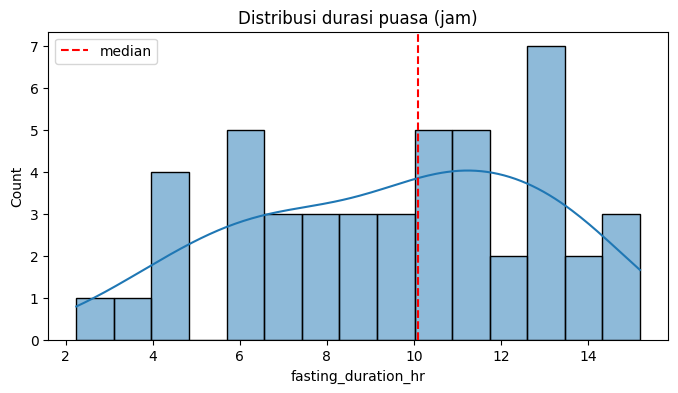

In [20]:
print(fasting_all['fasting_duration_hr'].describe())

plt.figure(figsize=(8,4))
sns.histplot(fasting_all['fasting_duration_hr'], bins=15, kde=True)
plt.axvline(fasting_all['fasting_duration_hr'].median(), color='red', linestyle='--', label='median')
plt.title("Distribusi durasi puasa (jam)")
plt.legend()
plt.show()

Threshold data fasting

In [21]:
def classify_hydration(hr):
    if hr < 10:
        return 'Well Hydrated'
    else:
        return 'At Risk of Dehydration'

fasting_all['hydration_status'] = fasting_all['fasting_duration_hr'].apply(classify_hydration)
fasting_all['hydration_status'].value_counts()

hydration_status
At Risk of Dehydration    24
Well Hydrated             23
Name: count, dtype: int64

kategori nonfasting diklasifikasikan sbg Normal karna dr dataset blg yang nonfasting ini subjek udah minum 1 jam sebelum jadi terhidrasi dong

In [22]:
meta_df_clean['hydration_status'] = np.where(
    meta_df_clean['session_type'] == 'nonfasting', 'Well Hydrated',
    meta_df_clean['fasting_duration_hr'].apply(lambda x: classify_hydration(x) if pd.notna(x) else None)
)
meta_df_clean['hydration_status'].value_counts(dropna=False)

hydration_status
Well Hydrated             100
At Risk of Dehydration     23
Name: count, dtype: int64

In [23]:
meta_df_clean = meta_df_clean.merge(
    result_df[['file', 'duration_min', 'sampling_rate_hz', 'gap_pct']],
    on='file', how='left'
)

class_duration = meta_df_clean.groupby('hydration_status')['duration_min'].sum().sort_values(ascending=False)
print(class_duration)
print("\nProporsi (%):")
print((class_duration / class_duration.sum() * 100).round(1))

hydration_status
Well Hydrated             16678.7
At Risk of Dehydration      452.5
Name: duration_min, dtype: float64

Proporsi (%):
hydration_status
Well Hydrated             97.4
At Risk of Dehydration     2.6
Name: duration_min, dtype: float64


cek ketersediaan 4 kolom sensor final (sesuai hardware: MAX30102, GSR, BME280) di semua file

In [24]:
required_cols = ['PPG_A13_CAL', 'GSR_Skin_Conductance_CAL', 'Temperature_BMP280_CAL', 'Pressure_BMP280_CAL']

def has_required_cols(path):
    with open(path) as f:
        f.readline()
        signal = f.readline().strip().split(',')
        caluncal = f.readline().strip().split(',')
    colnames = [f"{s}_{c}" for s, c in zip(signal, caluncal)]
    return all(c in colnames for c in required_cols)

meta_df_clean['has_required_sensors'] = meta_df_clean['path'].apply(has_required_cols)
meta_df_clean['has_required_sensors'].value_counts()

has_required_sensors
True    123
Name: count, dtype: int64

# **PREPROCESSING**

In [25]:
FS = 51.2  # sampling rate hasil EDA (Hz)

valid_files = meta_df_clean[meta_df_clean['has_required_sensors']].reset_index(drop=True)
print("Total file valid untuk training:", len(valid_files))
valid_files['hydration_status'].value_counts()

Total file valid untuk training: 123


hydration_status
Well Hydrated             100
At Risk of Dehydration     23
Name: count, dtype: int64

In [26]:
def load_signals(path):
    with open(path) as f:
        f.readline()
        signal = f.readline().strip().split(',')
        caluncal = f.readline().strip().split(',')
    colnames = [f"{s}_{c}" for s, c in zip(signal, caluncal)]

    needed = {
        'ppg': 'PPG_A13_CAL',
        'gsr': 'GSR_Skin_Conductance_CAL',
        'temp': 'Temperature_BMP280_CAL',
        'pressure': 'Pressure_BMP280_CAL',
    }
    idx_map = {k: colnames.index(v) for k, v in needed.items()}

    sorted_items = sorted(idx_map.items(), key=lambda x: x[1])
    sorted_names = [k for k, _ in sorted_items]
    sorted_positions = [v for _, v in sorted_items]

    df = pd.read_csv(path, skiprows=4, header=None, usecols=sorted_positions, names=sorted_names)
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df.dropna().reset_index(drop=True)

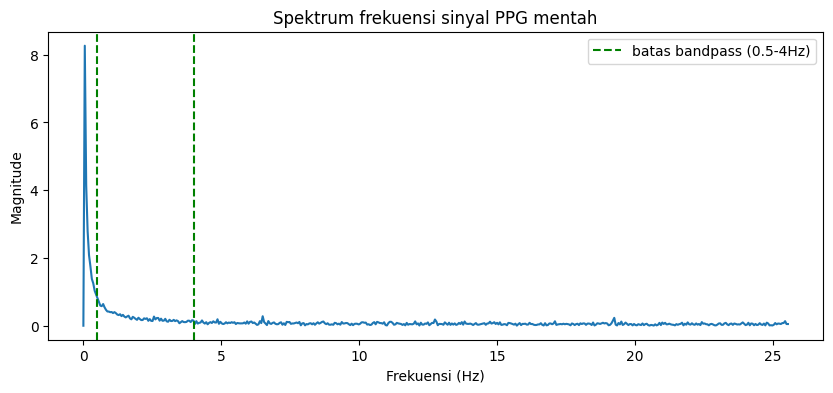

In [27]:
from scipy.fft import fft, fftfreq

sample_df = load_signals(valid_files.iloc[0]['path'])
sample_ppg = sample_df['ppg'].values[:1000]

n = len(sample_ppg)
yf = fft(sample_ppg - np.mean(sample_ppg))
xf = fftfreq(n, 1/FS)[:n//2]

plt.figure(figsize=(10,4))
plt.plot(xf, 2.0/n * np.abs(yf[:n//2]))
plt.title("Spektrum frekuensi sinyal PPG mentah")
plt.xlabel("Frekuensi (Hz)")
plt.ylabel("Magnitude")
plt.axvline(0.5, color='green', linestyle='--', label='batas bandpass (0.5-4Hz)')
plt.axvline(4, color='green', linestyle='--')
plt.legend()
plt.show()

### **PPG**

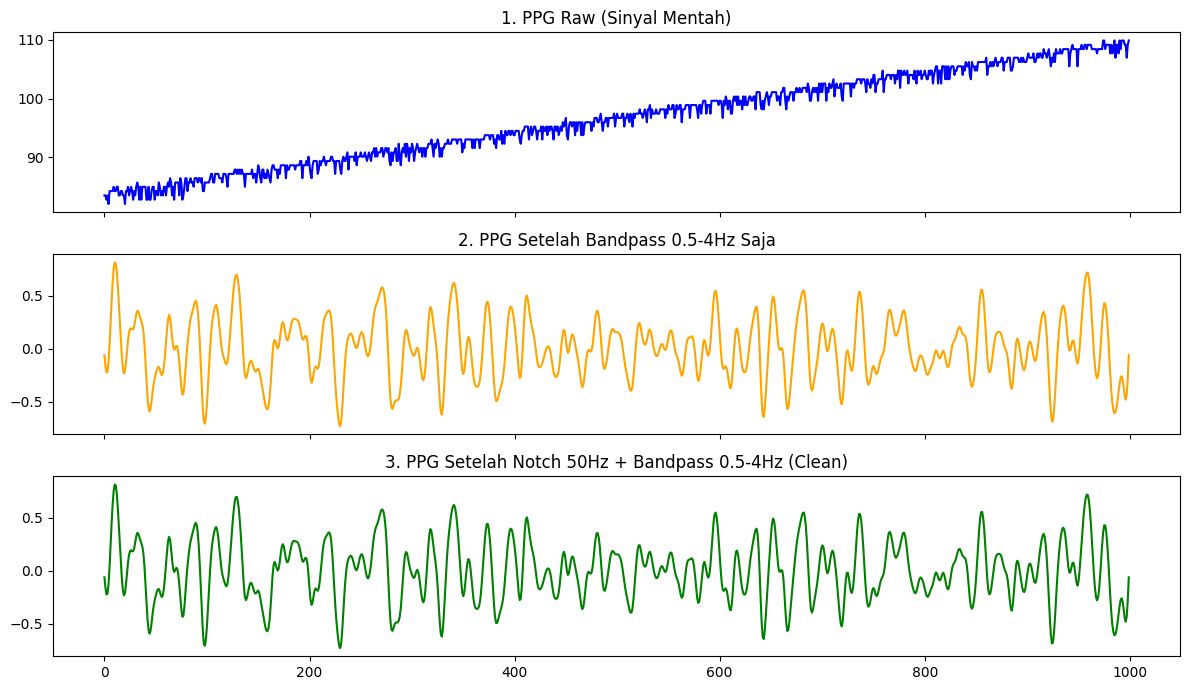

In [28]:
from scipy.signal import butter, filtfilt, iirnotch

def notch_filter(signal, fs=FS, freq=50.0, q=30.0):
    nyq = fs / 2
    # Notch filter hanya bisa aktif jika frekuensi notch di bawah frekuensi Nyquist
    if freq < nyq:
        w0 = freq / nyq
        b, a = iirnotch(w0, Q=q)
        return filtfilt(b, a, signal)
    return signal
def bandpass_filter(signal, fs=FS, low=0.5, high=4.0, order=2):
    nyq = fs / 2
    b, a = butter(order, [low / nyq, high / nyq], btype='band')
    return filtfilt(b, a, signal)
def clean_ppg(signal, fs=FS, low=0.5, high=4.0, order=2, notch_freq=50.0):
    # 1. Notch Filter (menghilangkan noise listrik 50Hz/60Hz)
    notch_filtered = notch_filter(signal, fs=fs, freq=notch_freq)
    # 2. Bandpass Filter (mengisolasi gelombang PPG 0.5-4Hz)
    bandpassed = bandpass_filter(notch_filtered, fs=fs, low=low, high=high, order=order)
    return bandpassed
# Ambil sample dari file pertama valid_files
sample_df = load_signals(valid_files.iloc[0]['path'])
sample_ppg = sample_df['ppg'].values[:1000]
# Terapkan pemfilteran gabungan (Notch + Bandpass)
filtered_ppg = clean_ppg(sample_ppg, fs=FS, notch_freq=50.0)
# Visualisasi perbandingan
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
axes[0].plot(sample_ppg, color='blue')
axes[0].set_title("1. PPG Raw (Sinyal Mentah)")
axes[1].plot(
    bandpass_filter(sample_ppg), color='orange'
)
axes[1].set_title("2. PPG Setelah Bandpass 0.5-4Hz Saja")
axes[2].plot(filtered_ppg, color='green')
axes[2].set_title("3. PPG Setelah Notch 50Hz + Bandpass 0.5-4Hz (Clean)")
plt.tight_layout()
plt.show()


sama aja tidak ada perubahan

Jumlah puncak: 23
Estimasi HR: 71.29113924050633 bpm


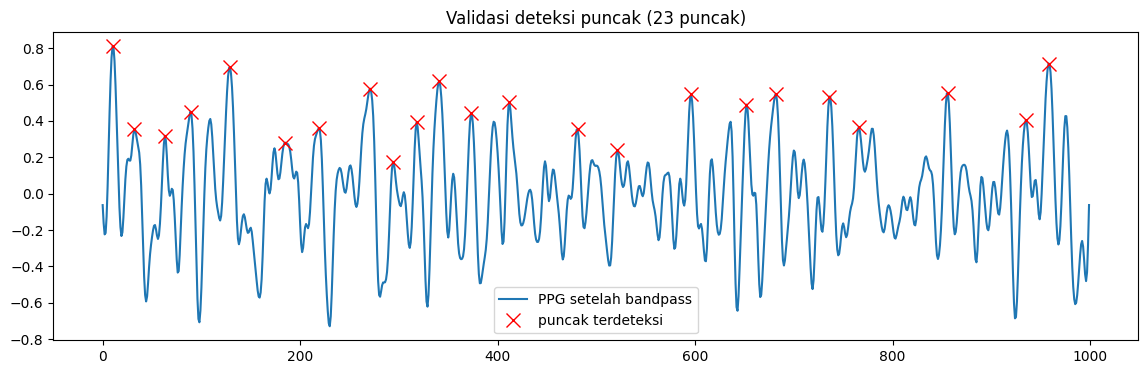

In [29]:
# deteksi puncak PPG
from scipy.signal import find_peaks

signal_range = np.ptp(filtered_ppg)  # max - min
peaks, _ = find_peaks(filtered_ppg, distance=FS*0.4, prominence=0.3*signal_range)

print("Jumlah puncak:", len(peaks))
print("Estimasi HR:", 60 / (np.mean(np.diff(peaks))/FS), "bpm")

plt.figure(figsize=(14,4))
plt.plot(filtered_ppg, label='PPG setelah bandpass')
plt.plot(peaks, filtered_ppg[peaks], "rx", markersize=10, label='puncak terdeteksi')
plt.title(f"Validasi deteksi puncak ({len(peaks)} puncak)")
plt.legend()
plt.show()

In [30]:
def robust_range(signal, low=5, high=95):
    return np.percentile(signal, high) - np.percentile(signal, low)

for i in range(3):
    df_test = load_signals(valid_files.iloc[i]['path'])
    seg = df_test['ppg'].values[:1000]
    filt = bandpass_filter(seg)
    rng = robust_range(filt)
    pk, _ = find_peaks(filt, distance=FS*0.4, prominence=0.3*rng)
    print(f"File {i}: {len(pk)} puncak, HR = {60/(np.mean(np.diff(pk))/FS):.1f} bpm")

File 0: 28 puncak, HR = 87.5 bpm
File 1: 21 puncak, HR = 68.0 bpm
File 2: 24 puncak, HR = 76.7 bpm


In [31]:
def has_motion_artifact(signal, threshold=6):
    median = np.median(signal)
    mad = np.median(np.abs(signal - median))
    if mad == 0:
        return False
    modified_z = 0.6745 * (signal - median) / mad
    return np.any(np.abs(modified_z) > threshold)

# tes ke File 1 yang punya artifact
df_test1 = load_signals(valid_files.iloc[1]['path'])
seg1 = df_test1['ppg'].values[:1000]
filt1 = bandpass_filter(seg1)
print("File 1 kedeteksi artifact?", has_motion_artifact(filt1))

# bandingkan ke File 0 & 2 yang sinyalnya bersih
for i in [0, 2]:
    df_test = load_signals(valid_files.iloc[i]['path'])
    filt = bandpass_filter(df_test['ppg'].values[:1000])
    print(f"File {i} kedeteksi artifact?", has_motion_artifact(filt))

File 1 kedeteksi artifact? True
File 0 kedeteksi artifact? False
File 2 kedeteksi artifact? False


CODE GUARDRAIL

In [32]:
# hitung RMSSD dari IBI
def compute_rmssd(ibi_ms):
    diff_ibi = np.diff(ibi_ms)
    return np.sqrt(np.mean(diff_ibi**2))

def clean_ibi(ibi_ms, min_ibi=300, max_ibi=1500, max_dev_ratio=0.3):
    # tahap 1: buang yang di luar rentang fisiologis absolut
    ibi_ms = ibi_ms[(ibi_ms >= min_ibi) & (ibi_ms <= max_ibi)]
    if len(ibi_ms) < 3:
        return ibi_ms

    # tahap 2: buang yang menyimpang jauh dari median IBI window ini
    # (indikasi puncak ganda/kelewat, bukan variabilitas HRV asli)
    median_ibi = np.median(ibi_ms)
    mask = np.abs(ibi_ms - median_ibi) / median_ibi <= max_dev_ratio
    return ibi_ms[mask]

def extract_ppg_features(ppg_segment, fs=FS):
    filtered = bandpass_filter(ppg_segment, fs=fs)

    if has_motion_artifact(filtered):
        return {'rmssd': np.nan, 'mean_hr': np.nan, 'sdnn': np.nan, 'pnn50': np.nan, 'n_peaks': 0}

    rng = robust_range(filtered)
    peaks, _ = find_peaks(filtered, distance=fs*0.4, prominence=0.3*rng)

    if len(peaks) < 3:
        return {'rmssd': np.nan, 'mean_hr': np.nan, 'sdnn': np.nan, 'pnn50': np.nan, 'n_peaks': len(peaks)}

    ibi_raw = np.diff(peaks) / fs * 1000
    ibi = clean_ibi(ibi_raw)

    if len(ibi) < 3 or (len(ibi_raw) - len(ibi)) / len(ibi_raw) > 0.3:
        return {'rmssd': np.nan, 'mean_hr': np.nan, 'sdnn': np.nan, 'pnn50': np.nan, 'n_peaks': len(peaks)}

    mean_hr = 60000 / ibi.mean()

    # guard akhir: HR agregat harus tetap dalam rentang fisiologis wajar
    if not (40 <= mean_hr <= 180):
        return {'rmssd': np.nan, 'mean_hr': np.nan, 'sdnn': np.nan, 'pnn50': np.nan, 'n_peaks': len(peaks)}

    rmssd = compute_rmssd(ibi)
    sdnn = np.std(ibi)
    diff_ibi = np.abs(np.diff(ibi))
    pnn50 = (diff_ibi > 50).sum() / len(diff_ibi) * 100 if len(diff_ibi) > 0 else np.nan

    return {'rmssd': rmssd, 'mean_hr': mean_hr, 'sdnn': sdnn, 'pnn50': pnn50, 'n_peaks': len(peaks)}

Apakah dianggap Motion Artifact? True
Jumlah peaks terdeteksi: 20


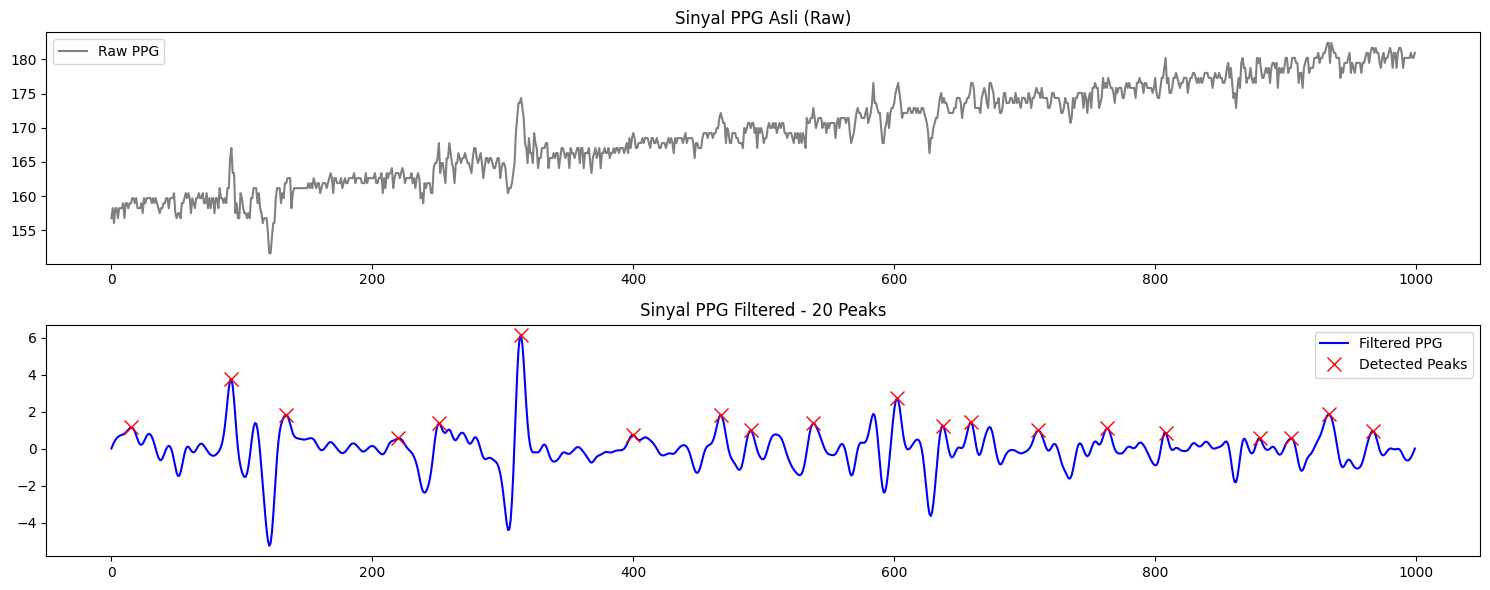

In [33]:
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Ambil data sampel
fs = 51.2 
seg = load_signals(valid_files.iloc[0]['path'])['ppg'].values[3000:4000]
# Filter sinyal
filtered = bandpass_filter(seg, fs=fs)
# Hitung range dan deteksi peaks
rng = robust_range(filtered)
peaks, properties = find_peaks(filtered, distance=fs*0.4, prominence=0.3*rng)
# Cek output motion artifact-nya (apakah dia biang keroknya?)
is_artifact = has_motion_artifact(filtered)
print(f"Apakah dianggap Motion Artifact? {is_artifact}")
print(f"Jumlah peaks terdeteksi: {len(peaks)}")

plt.figure(figsize=(15, 6))
plt.subplot(2, 1, 1)
plt.plot(seg, label='Raw PPG', color='gray')
plt.title('Sinyal PPG Asli (Raw)')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(filtered, label='Filtered PPG', color='blue')
if len(peaks) > 0:
    plt.plot(peaks, filtered[peaks], "x", color='red', markersize=10, label='Detected Peaks')
plt.title(f'Sinyal PPG Filtered - {len(peaks)} Peaks')
plt.legend()

plt.tight_layout()
plt.show()

CEK 5 FILE PERTAMA

In [34]:
import pandas as pd
import numpy as np

num_files_to_test = 10

for file_idx in range(num_files_to_test):
    print(f"               FILE KE-{file_idx}                ")
    
    # Ambil sinyal PPG penuh dari file ke-file_idx
    full_signal = load_signals(valid_files.iloc[file_idx]['path'])['ppg'].values
    window_len = 1000
    all_window_results = []
    
    print(f"Total data: {len(full_signal)} sampel...")
    
    # Looping dari awal sampai akhir file per 1000 data
    for start_idx in range(0, len(full_signal), window_len):
        end_idx = start_idx + window_len
        
        # Berhenti kalau sisa data di akhir kurang dari 1000 (window tidak utuh)
        if end_idx > len(full_signal):
            break
            
        # Ambil potongan sinyal
        window_segment = full_signal[start_idx:end_idx]
        
        # Ekstrak fitur menggunakan fungsi buatanmu
        features = extract_ppg_features(window_segment)
        
        # Catat ini window ke berapa biar gampang dilacak
        features['window_start'] = start_idx
        
        all_window_results.append(features)

    df_file_results = pd.DataFrame(all_window_results)
    
    total_windows = len(df_file_results)
    df_valid = df_file_results.dropna(subset=['mean_hr']) # Filter hanya yang BUKAN NaN
    valid_count = len(df_valid)
    valid_pct = (valid_count / total_windows) * 100 if total_windows > 0 else 0
    fail_pct = ((total_windows - valid_count) / total_windows) * 100 if total_windows > 0 else 0
    
    print(f"Total potongan window  : {total_windows}")
    print(f"Window valid (sukses)  : {valid_count} ({valid_pct:.1f}%)")
    print(f"Window gagal (dibuang) : {total_windows - valid_count} ({fail_pct:.1f}%)")
    
    # Lihat rata-rata fitur dari window yang valid untuk mewakili file tersebut
    print("--- Nilai Rata-rata Fitur ---")
    if valid_count > 0:
        print(df_valid[['rmssd', 'mean_hr', 'sdnn', 'pnn50']].mean())
    else:
        print("Yah, tidak ada window yang valid untuk file ini (0%).")

               FILE KE-0                
Total data: 388976 sampel...
Total potongan window  : 388
Window valid (sukses)  : 122 (31.4%)
Window gagal (dibuang) : 266 (68.6%)
--- Nilai Rata-rata Fitur ---
rmssd      154.590855
mean_hr     93.069561
sdnn       107.740557
pnn50       76.803061
dtype: float64
               FILE KE-1                
Total data: 16759 sampel...
Total potongan window  : 16
Window valid (sukses)  : 12 (75.0%)
Window gagal (dibuang) : 4 (25.0%)
--- Nilai Rata-rata Fitur ---
rmssd      106.456405
mean_hr     77.557513
sdnn        70.661926
pnn50       55.258228
dtype: float64
               FILE KE-2                
Total data: 361497 sampel...
Total potongan window  : 361
Window valid (sukses)  : 358 (99.2%)
Window gagal (dibuang) : 3 (0.8%)
--- Nilai Rata-rata Fitur ---
rmssd      48.604245
mean_hr    74.979414
sdnn       46.022968
pnn50      28.490501
dtype: float64
               FILE KE-3                
Total data: 23958 sampel...
Total potongan window  : 

### **GSR**

In [35]:
from scipy.stats import entropy as shannon_entropy

def extract_gsr_features(gsr_segment, fs=51.2, bins=10):
    # Filter sinyalnya dulu sebelum dihitung!
    gsr_clean = lowpass_filter_gsr(gsr_segment, fs=fs)
    
    mean_val = np.mean(gsr_clean)
    var_val = np.var(gsr_clean)
    
    # Hitung entropy dari sinyal yang sudah bersih
    hist, _ = np.histogram(gsr_clean, bins=bins, density=True)
    hist = hist[hist > 0]
    entropy_val = shannon_entropy(hist) if len(hist) > 0 else 0
    
    return {
        'gsr_mean': mean_val, 
        'gsr_var': var_val, 
        'gsr_entropy': entropy_val
    }

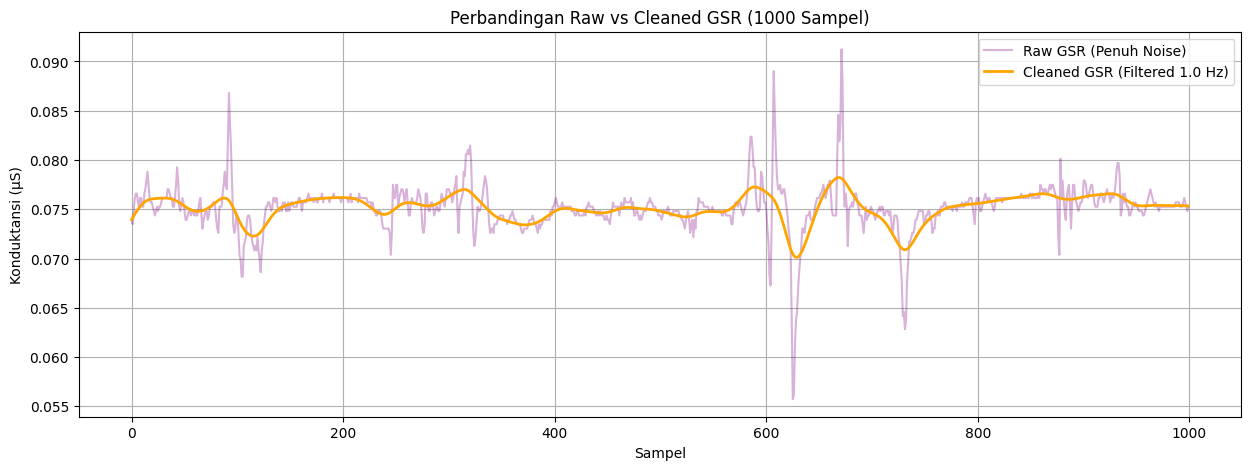

In [36]:
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt

# Fungsi Low-Pass Filter
def lowpass_filter_gsr(signal, fs=51.2, cutoff=1.0, order=2):
    nyq = 0.5 * fs
    b, a = butter(order, cutoff / nyq, btype='low')
    return filtfilt(b, a, signal)

# Ambil data 10.000 sampel
gsr_raw = load_signals(valid_files.iloc[0]['path'])['gsr'].values[3000:4000]  

# filter
gsr_clean = lowpass_filter_gsr(gsr_raw)

#plot
plt.figure(figsize=(15, 5))
plt.plot(gsr_raw, color='purple', alpha=0.3, label='Raw GSR (Penuh Noise)')
plt.plot(gsr_clean, color='orange', linewidth=2, label='Cleaned GSR (Filtered 1.0 Hz)')
plt.title('Perbandingan Raw vs Cleaned GSR (1000 Sampel)')
plt.ylabel('Konduktansi (µS)')
plt.xlabel('Sampel')
plt.legend()
plt.grid(True)
plt.show()

In [37]:
num_files_to_test = 5

for file_idx in range(num_files_to_test):
    print(f"\n=======================================================")
    print(f"               MEMPROSES FILE KE-{file_idx} (GSR)          ")
    print(f"=======================================================")
    
    # 1. Ambil sinyal GSR penuh
    full_signal = load_signals(valid_files.iloc[file_idx]['path'])['gsr'].values
    
    # 2. Setup parameter window (1000 data)
    window_len = 1000
    all_window_results = []
    
    print(f"Total data: {len(full_signal)} sampel...")
    
    # 3. Looping dari awal sampai akhir file per 1000 data
    for start_idx in range(0, len(full_signal), window_len):
        end_idx = start_idx + window_len
        
        # Berhenti kalau sisa data di akhir kurang dari 1000 (window tidak utuh)
        if end_idx > len(full_signal):
            break
            
        # Ambil potongan sinyal
        window_segment = full_signal[start_idx:end_idx]
        
        # Ekstrak fitur menggunakan fungsi filter & ekstraksi buatanmu
        features = extract_gsr_features(window_segment)
        features['window_start'] = start_idx
        
        all_window_results.append(features)

    # 4. Jadikan DataFrame
    df_file_results = pd.DataFrame(all_window_results)
    total_windows = len(df_file_results)
    
    print(f"Total potongan window  : {total_windows}")
    print("--- Nilai Rata-rata Fitur GSR ---")
    
    if total_windows > 0:
        # Menampilkan rata-rata dari fitur gsr_mean, gsr_var, dan gsr_entropy
        print(df_file_results[['gsr_mean', 'gsr_var', 'gsr_entropy']].mean())
    else:
        print("Tidak ada window yang berhasil diekstrak.")


               MEMPROSES FILE KE-0 (GSR)          
Total data: 388976 sampel...
Total potongan window  : 388
--- Nilai Rata-rata Fitur GSR ---
gsr_mean       10.702748
gsr_var         0.377613
gsr_entropy     2.006010
dtype: float64

               MEMPROSES FILE KE-1 (GSR)          
Total data: 16759 sampel...
Total potongan window  : 16
--- Nilai Rata-rata Fitur GSR ---
gsr_mean       0.186055
gsr_var        0.000056
gsr_entropy    1.969220
dtype: float64

               MEMPROSES FILE KE-2 (GSR)          
Total data: 361497 sampel...
Total potongan window  : 361
--- Nilai Rata-rata Fitur GSR ---
gsr_mean       0.255257
gsr_var        0.000034
gsr_entropy    1.857008
dtype: float64

               MEMPROSES FILE KE-3 (GSR)          
Total data: 23958 sampel...
Total potongan window  : 23
--- Nilai Rata-rata Fitur GSR ---
gsr_mean       0.103426
gsr_var        0.000005
gsr_entropy    2.035553
dtype: float64

               MEMPROSES FILE KE-4 (GSR)          
Total data: 10915 sampel.

### **WINDOWING**

In [38]:
def create_windows(df, fs=FS, window_sec=30, overlap=0.5):
    window_size = int(window_sec * fs)
    step_size = int(window_size * (1 - overlap))
    windows = []
    
    for start in range(0, len(df) - window_size + 1, step_size):
        end = start + window_size
        windows.append(df.iloc[start:end])
        
    return windows

def extract_window_features(window_df):
    ppg_feats = extract_ppg_features(window_df['ppg'].values)
    gsr_feats = extract_gsr_features(window_df['gsr'].values)
    return {**ppg_feats, **gsr_feats}

# Test ke 1 file (sample_df)
test_windows = create_windows(sample_df)
print("Jumlah window dari 1 file:", len(test_windows))

sample_features = extract_window_features(test_windows[0])
print(sample_features)

Jumlah window dari 1 file: 505
{'rmssd': nan, 'mean_hr': nan, 'sdnn': nan, 'pnn50': nan, 'n_peaks': 41, 'gsr_mean': np.float64(0.07355529660617395), 'gsr_var': np.float64(2.2414502937721712e-07), 'gsr_entropy': np.float64(1.7195177594840494)}


In [39]:
import pandas as pd
import time

all_windows_data = []
total_files = len(valid_files)
start_time = time.time()

for index, row in valid_files.iterrows():
    file_path = row['path']
    
    # Tracker sederhana biar ketahuan kalau berjalan
    if (index + 1) % 10 == 0 or (index + 1) == total_files:
        print(f"Memproses file {index + 1}/{total_files}...")
        
    try:
        # 1. Load sinyal utuh & potong jadi sliding windows
        df_signal = load_signals(file_path)
        windows = create_windows(df_signal)
        
        # 2. Ekstrak fitur per window
        for w_idx, w_df in enumerate(windows):
            feats = extract_window_features(w_df)
            
            # 3. Sisipkan Target Label (Regresi) dan Metadata
            feats['fasting_duration_hr'] = row['fasting_duration_hr'] # Target utama ML
            feats['hydration_status'] = row['hydration_status']       # Untuk rules dashboard
            feats['session_type'] = row['session_type']
            feats['subject_id'] = row['subject_id'] 
            feats['file'] = row['file']
            feats['window_id'] = w_idx
            
            all_windows_data.append(feats)
            
    except Exception as e:
        print(f"⚠️ Error memproses file indeks {index} ({file_path}): {e}")

# 4. Konversi list ke Pandas DataFrame
feature_df = pd.DataFrame(all_windows_data)

# 5. Ekspor ke CSV agar aman
output_csv = "dataset_final_features.csv"
feature_df.to_csv(output_csv, index=False)

waktu_eksekusi = (time.time() - start_time) / 60
print("\n✅ === EKSTRAKSI SELESAI ===")
print(f"Waktu eksekusi   : {waktu_eksekusi:.2f} menit")
print(f"Total baris data : {len(feature_df)} windows")
print(f"File tersimpan   : {output_csv}")

# Cek persentase NaN dari PPG
nan_ppg = feature_df['mean_hr'].isna().sum()
persentase_nan = (nan_ppg / len(feature_df)) * 100
print(f"\nStatistik Guardrail PPG: {nan_ppg} window ({persentase_nan:.1f}%) di-drop karena noise/gerakan.")

Memproses file 10/123...
Memproses file 20/123...
Memproses file 30/123...
Memproses file 40/123...
Memproses file 50/123...
Memproses file 60/123...
Memproses file 70/123...
Memproses file 80/123...
Memproses file 90/123...
Memproses file 100/123...
Memproses file 110/123...
Memproses file 120/123...
Memproses file 123/123...

✅ === EKSTRAKSI SELESAI ===
Waktu eksekusi   : 3.36 menit
Total baris data : 12821 windows
File tersimpan   : dataset_final_features.csv

Statistik Guardrail PPG: 9018 window (70.3%) di-drop karena noise/gerakan.


In [40]:
# Load dataset final yang baru saja kita simpan
df = pd.read_csv("dataset_final_features.csv")

print(f"Total baris data loaded: {len(df)}")
print("Jumlah kolom:", len(df.columns))
print("\nContoh 3 baris teratas:")
display(df.head(3))

# Cek distribusi target regresi kita (fasting_duration_hr)
print("\nStatistik Target (Jam Sejak Minum):")
print(df['fasting_duration_hr'].describe())

Total baris data loaded: 12821
Jumlah kolom: 14

Contoh 3 baris teratas:


,rmssd,mean_hr,sdnn,pnn50,n_peaks,gsr_mean,gsr_var,gsr_entropy,fasting_duration_hr,hydration_status,session_type,subject_id,file,window_id
0,NaN,NaN,NaN,NaN,41,0.073555,2.241450e-07,1.719518,6.174444,Well Hydrated,fasting,S1,20210408100028Apr8_10_00_fasting.csv,0
1,NaN,NaN,NaN,NaN,40,0.072922,3.884952e-07,1.559357,6.174444,Well Hydrated,fasting,S1,20210408100028Apr8_10_00_fasting.csv,1
2,NaN,NaN,NaN,NaN,0,0.073358,3.449900e-06,1.430142,6.174444,Well Hydrated,fasting,S1,20210408100028Apr8_10_00_fasting.csv,2



Statistik Target (Jam Sejak Minum):
count    4262.000000
mean        8.895759
std         3.114390
min         2.245278
25%         6.174444
50%         9.121111
75%        11.492778
max        15.197500
Name: fasting_duration_hr, dtype: float64


In [41]:
# 1. Bersihkan dataframe dari baris yang target y-nya NaN
df_clean = df.dropna(subset=['fasting_duration_hr']).copy()

print(f"Jumlah baris awal: {len(df)}")
print(f"Jumlah baris setelah membuang target y yang NaN: {len(df_clean)}")

# 2. Definisikan ulang X, y, dan groups dari df_clean
features_to_drop = ['subject_id', 'file', 'hydration_status', 'session_type', 'window_id', 'fasting_duration_hr']
X = df_clean.drop(columns=[col for col in features_to_drop if col in df_clean.columns])
y = df_clean['fasting_duration_hr']
groups = df_clean['subject_id']

# 3. Imputasi fitur PPG yang NaN dengan -1 (seperti sebelumnya)
ppg_cols = ['mean_hr', 'rmssd', 'sdnn', 'pnn50', 'n_peaks']
for col in ppg_cols:
    if col in X.columns:
        X[col] = X[col].fillna(-1)

print(f"Sisa NaN di seluruh X dan y: {X.isna().sum().sum() + y.isna().sum()}")

Jumlah baris awal: 12821
Jumlah baris setelah membuang target y yang NaN: 4262
Sisa NaN di seluruh X dan y: 0


At Risk of Dehydration paling sedikit dan berasal dari sesi fasting yang durasinya >= 10 jam

## **SPLIT N TRAIN**

REVISION (bismilla)

In [61]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. LOAD DATA: Hanya rekaman dengan target kontinu terukur.
df = pd.read_csv("dataset_final_features.csv")
df_clean = df.loc[
    df['session_type'].eq('fasting') & df['fasting_duration_hr'].notna()
].copy().reset_index(drop=True)

# 2. PEMBUATAN EPISODE ID (Mencegah kebocoran data di hari puasa yang sama)
record_start = pd.to_datetime(
    df_clean['file'].str.extract(r'^(\d{14})')[0], format='%Y%m%d%H%M%S'
)
fasting_start = record_start - pd.to_timedelta(df_clean['fasting_duration_hr'], unit='h')
df_clean['episode_id'] = (
    df_clean['subject_id'].astype(str) + '_' + fasting_start.dt.round('min').dt.strftime('%Y%m%d%H%M%S')
)

episode_count = df_clean.groupby('subject_id')['episode_id'].nunique()
eligible_subjects = episode_count[episode_count >= 2].index
excluded_subjects = episode_count[episode_count < 2]

df_clean = df_clean[df_clean['subject_id'].isin(eligible_subjects)].copy().reset_index(drop=True)
print(f"Window fasting dengan target terukur: {len(df_clean)}")
print(f"Subjek evaluasi (>= 2 episode): {eligible_subjects.tolist()}")
if not excluded_subjects.empty:
    print(f"Subjek tidak dievaluasi (dilewati): {excluded_subjects.to_dict()}")

# Pastikan tipe data numerik
fitur_numerik = ['gsr_mean', 'gsr_var', 'gsr_entropy', 'mean_hr', 'rmssd', 'sdnn', 'pnn50', 'n_peaks']
for col in fitur_numerik:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype(float)

# Flag kualitas PPG
ppg_cols = ['mean_hr', 'rmssd', 'sdnn', 'pnn50', 'n_peaks']
df_clean['ppg_available'] = (
    df_clean[ppg_cols].notna().all(axis=1) & df_clean[ppg_cols].ne(-1).all(axis=1)
).astype('int8')

# 3. SETUP VARIABEL ML
features_to_drop = ['subject_id', 'file', 'episode_id', 'hydration_status', 'session_type', 'window_id', 'fasting_duration_hr']
X = df_clean.drop(columns=[col for col in features_to_drop if col in df_clean.columns])
y = df_clean['fasting_duration_hr']
groups = df_clean['episode_id']  

# 4. CROSS VALIDATION YANG SAH (Z-Score di dalam Fold)
gkf = GroupKFold(n_splits=5)
rf_model = RandomForestRegressor(
    n_estimators=100, max_depth=10, min_samples_leaf=4, random_state=42, n_jobs=-1
)

oof_rows = []
gsr_cols = ['gsr_mean', 'gsr_var', 'gsr_entropy']

print("\nMemulai 5-Fold CV intra-subjek per episode...")

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups), 1):
    X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
    y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()
    
    train_subjects = df_clean.iloc[train_idx]['subject_id']
    test_subjects = df_clean.iloc[test_idx]['subject_id']
    if not set(test_subjects).issubset(set(train_subjects)):
        raise ValueError('Fold test berisi subjek tanpa episode kalibrasi di train.')

    # A. Z-score GSR
    for col in gsr_cols:
        raw_stats = pd.DataFrame({
            'subject_id': train_subjects.to_numpy(), 'value': X_train[col].to_numpy()
        }).groupby('subject_id')['value'].agg(['mean', 'std'])
        means = raw_stats['mean']
        stds = raw_stats['std'].replace(0, 1).fillna(1)
        X_train[col] = (X_train[col] - train_subjects.map(means)) / train_subjects.map(stds)
        X_test[col] = (X_test[col] - test_subjects.map(means)) / test_subjects.map(stds)

    # B. Z-score PPG valid saja
    train_ppg_valid = X_train['ppg_available'].eq(1)
    test_ppg_valid = X_test['ppg_available'].eq(1)
    for col in ppg_cols:
        ppg_stats = pd.DataFrame({
            'subject_id': train_subjects.loc[train_ppg_valid].to_numpy(),
            'value': X_train.loc[train_ppg_valid, col].to_numpy(),
        }).groupby('subject_id')['value'].agg(['mean', 'std'])
        means = ppg_stats['mean']
        stds = ppg_stats['std'].replace(0, 1).fillna(1)
        
        X_train.loc[train_ppg_valid, col] = (
            X_train.loc[train_ppg_valid, col] - train_subjects.loc[train_ppg_valid].map(means)
        ) / train_subjects.loc[train_ppg_valid].map(stds)
        X_test.loc[test_ppg_valid, col] = (
            X_test.loc[test_ppg_valid, col] - test_subjects.loc[test_ppg_valid].map(means)
        ) / test_subjects.loc[test_ppg_valid].map(stds)
        
        X_train.loc[~train_ppg_valid, col] = 0.0
        X_test.loc[~test_ppg_valid, col] = 0.0

    # Train & Predict
    rf_model.fit(X_train, y_train)
    y_pred = rf_model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    oof_rows.append(pd.DataFrame({
        'subject_id': df_clean.iloc[test_idx]['subject_id'].to_numpy(),
        'episode_id': df_clean.iloc[test_idx]['episode_id'].to_numpy(),
        'file': df_clean.iloc[test_idx]['file'].to_numpy(),
        'ppg_available': X_test['ppg_available'].to_numpy(),
        'y_true': y_test.to_numpy(),
        'y_pred': y_pred,
    }))
    print(f"Fold {fold}: MAE = {mae:.4f} jam")

oof_predictions = pd.concat(oof_rows, ignore_index=True)
oof_by_file = oof_predictions.groupby(['subject_id', 'episode_id', 'file'], as_index=False).agg(
    y_true=('y_true', 'first'),
    y_pred=('y_pred', 'mean'),
    ppg_available=('ppg_available', 'mean'),
)

print("\n=== HASIL EVALUASI LEVEL REKAMAN (METRIK UTAMA) ===")
print(f"Jumlah rekaman OOF: {len(oof_by_file)}")
print(f"MAE  : {mean_absolute_error(oof_by_file['y_true'], oof_by_file['y_pred']):.3f} jam")
print(f"RMSE : {np.sqrt(mean_squared_error(oof_by_file['y_true'], oof_by_file['y_pred'])):.3f} jam")

# Menghitung metrik per grup TANPA warning Deprecation
print("\nMAE Per Subjek:")
mae_per_subject = {
    name: mean_absolute_error(grp['y_true'], grp['y_pred']) 
    for name, grp in oof_by_file.groupby('subject_id')
}
print(pd.Series(mae_per_subject, name='mae_hours').to_frame())

print("\n MAE Berdasarkan Ketersediaan PPG:")
oof_ppg = oof_by_file.assign(
    ppg_state=np.where(oof_by_file['ppg_available'] >= 0.5, 'PPG Valid', 'PPG Diimputasi')
)
mae_per_ppg = {
    name: mean_absolute_error(grp['y_true'], grp['y_pred']) 
    for name, grp in oof_ppg.groupby('ppg_state')
}
print(pd.Series(mae_per_ppg, name='mae_hours').to_frame())

Window fasting dengan target terukur: 3942
Subjek evaluasi (>= 2 episode): ['S1', 'S2', 'S4', 'S5', 'S6']
Subjek tidak dievaluasi (dilewati): {'S3': 1}

Memulai 5-Fold CV intra-subjek per episode...
Fold 1: MAE = 3.3015 jam
Fold 2: MAE = 2.8283 jam
Fold 3: MAE = 2.7937 jam
Fold 4: MAE = 2.1140 jam
Fold 5: MAE = 2.5993 jam

=== HASIL EVALUASI LEVEL REKAMAN (METRIK UTAMA) ===
Jumlah rekaman OOF: 35
MAE  : 3.109 jam
RMSE : 3.879 jam

MAE Per Subjek:
    mae_hours
S1   3.522435
S2   3.067599
S4   2.457596
S5   0.830425
S6   3.085254

 MAE Berdasarkan Ketersediaan PPG:
                mae_hours
PPG Diimputasi   3.245744
PPG Valid        2.289226


EVALUASI

In [62]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor

# 1. LOAD DATA 
df = pd.read_csv("dataset_final_features.csv")
df_clean = df.loc[df['session_type'].eq('fasting') & df['fasting_duration_hr'].notna()].copy()

fitur_numerik = ['gsr_mean', 'gsr_var', 'gsr_entropy', 'mean_hr', 'rmssd', 'sdnn', 'pnn50', 'n_peaks']
for col in fitur_numerik:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype(float)

ppg_cols = ['mean_hr', 'rmssd', 'sdnn', 'pnn50', 'n_peaks']
df_clean['ppg_available'] = (
    df_clean[ppg_cols].notna().all(axis=1) & df_clean[ppg_cols].ne(-1).all(axis=1)
).astype('int8')

# =======================================================
# 2. AUTOMATIC LOOPING UNTUK SEMUA SUBJEK
# =======================================================
features_to_drop = ['subject_id', 'file', 'episode_id', 'hydration_status', 'session_type', 'window_id', 'fasting_duration_hr']
gsr_cols = ['gsr_mean', 'gsr_var', 'gsr_entropy']

# Cari subjek yang memiliki minimal 2 file rekaman
file_counts = df_clean.groupby('subject_id')['file'].nunique()
eligible_subjects = file_counts[file_counts >= 2].index.tolist()

print(f"Memulai Simulasi Inferensi Dunia Nyata untuk {len(eligible_subjects)} Subjek...\n")
print("="*60)

all_errors = []

for target_subject in eligible_subjects:
    df_sub = df_clean[df_clean['subject_id'] == target_subject].copy()
    
    # Urutkan berdasarkan waktu file
    df_sub = df_sub.sort_values(by='file')
    daftar_file = df_sub['file'].unique()
    
    # File terakhir jadi Test, sisanya jadi Train (Kalibrasi)
    test_file = daftar_file[-1] 
    train_df = df_sub[df_sub['file'] != test_file].copy()
    test_df = df_sub[df_sub['file'] == test_file].copy()
    
    X_train = train_df.drop(columns=[col for col in features_to_drop if col in train_df.columns])
    y_train = train_df['fasting_duration_hr']
    
    X_test = test_df.drop(columns=[col for col in features_to_drop if col in test_df.columns])
    y_true_value = test_df['fasting_duration_hr'].iloc[0] 
    
    # A. Normalisasi Z-Score HANYA dari riwayat Train
    for col in gsr_cols:
        mean_val = X_train[col].mean()
        std_val = X_train[col].std()
        if std_val == 0: std_val = 1
        
        X_train[col] = (X_train[col] - mean_val) / std_val
        X_test[col] = (X_test[col] - mean_val) / std_val

    # B. Amankan sinyal PPG yang rusak
    for col in ppg_cols:
        X_train.loc[X_train['ppg_available'] == 0, col] = 0.0
        X_test.loc[X_test['ppg_available'] == 0, col] = 0.0

    # 3. TRAINING MODEL PERSONAL
    rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_leaf=4, random_state=42, n_jobs=-1)
    rf_model.fit(X_train, y_train)

    # 4. INFERENSI (TEBAK FILE BARU)
    y_pred_windows = rf_model.predict(X_test)
    final_prediction = np.mean(y_pred_windows)
    
    error = abs(y_true_value - final_prediction)
    all_errors.append(error)
    ppg_nyala = (test_df['ppg_available'] == 1).mean() * 100
    
    # 5. CETAK HASIL PER SUBJEK
    print(f"Subjek {target_subject} | Histori Kalibrasi: {train_df['file'].nunique()} file")
    print(f"   Kunci Jawaban  : {y_true_value:.2f} jam puasa")
    print(f"   Tebakan ML     : {final_prediction:.2f} jam puasa")
    print(f"   Error Meleset  : {error:.2f} jam  (PPG Valid: {ppg_nyala:.0f}%)")
    print("-" * 60)

print(f"RATA-RATA ERROR (MAE) DARI SELURUH SIMULASI: {np.mean(all_errors):.2f} jam")
print("="*60)

Memulai Simulasi Inferensi Dunia Nyata untuk 6 Subjek...

Subjek S1 | Histori Kalibrasi: 20 file
   Kunci Jawaban  : 10.87 jam puasa
   Tebakan ML     : 8.91 jam puasa
   Error Meleset  : 1.97 jam  (PPG Valid: 8%)
------------------------------------------------------------
Subjek S2 | Histori Kalibrasi: 3 file
   Kunci Jawaban  : 13.13 jam puasa
   Tebakan ML     : 9.83 jam puasa
   Error Meleset  : 3.30 jam  (PPG Valid: 38%)
------------------------------------------------------------
Subjek S3 | Histori Kalibrasi: 3 file
   Kunci Jawaban  : 14.80 jam puasa
   Tebakan ML     : 14.37 jam puasa
   Error Meleset  : 0.43 jam  (PPG Valid: 8%)
------------------------------------------------------------
Subjek S4 | Histori Kalibrasi: 5 file
   Kunci Jawaban  : 2.25 jam puasa
   Tebakan ML     : 11.06 jam puasa
   Error Meleset  : 8.82 jam  (PPG Valid: 7%)
------------------------------------------------------------
Subjek S5 | Histori Kalibrasi: 1 file
   Kunci Jawaban  : 9.79 jam puasa
  

CONVERT MODEL

In [64]:
!pip install emlearn


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [66]:
import emlearn
from sklearn.ensemble import RandomForestRegressor

# Latih Ulang Model dengan Parameter Khusus TinyML (Extreme Pruning)
# jumlah pohon dikurangi (n_estimators) agar hemat Flash Memory ESP32
rf_tinyml = RandomForestRegressor(
    n_estimators=35,     # 35 pohon sudah sangat cukup & ringan
    max_depth=8,         # Kedalaman dipangkas agar tidak boros RAM
    min_samples_leaf=4,
    random_state=42
)

# Asumsi: X_train dan y_train menggunakan gabungan data seluruh subjek kalibrasi
rf_tinyml.fit(X_train, y_train)
print("Model RF khusus TinyML berhasil dilatih.")

# Ekstraksi Model menjadi bahasa C (Array-based Encoding)
# emlearn akan mengubah node pohon menjadi array 1 dimensi yang hemat memori
c_model = emlearn.convert(rf_tinyml)

# Simpan ke file C Header (.h)
nama_file = 'rf_hydration_model.h'
c_model.save(file=nama_file, name='hydration_rf')

print(f"SUKSES! Model berhasil diekspor ke file: {nama_file}")
print("Silakan pindahkan file ini ke dalam folder project Arduino IDE / PlatformIO kamu.")

Model RF khusus TinyML berhasil dilatih.
SUKSES! Model berhasil diekspor ke file: rf_hydration_model.h
Silakan pindahkan file ini ke dalam folder project Arduino IDE / PlatformIO kamu.


In [ ]:
import pandas as pd
import numpy as np
import emlearn
from sklearn.ensemble import RandomForestRegressor

df = pd.read_csv("dataset_final_features.csv")
df_clean = df.loc[df['session_type'].eq('fasting') & df['fasting_duration_hr'].notna()].copy()

fitur_numerik = ['gsr_mean', 'gsr_var', 'gsr_entropy', 'mean_hr', 'rmssd', 'sdnn', 'pnn50', 'n_peaks']
for col in fitur_numerik:
    df_clean[col] = df_clean[col].astype(float)

ppg_cols = ['mean_hr', 'rmssd', 'sdnn', 'pnn50', 'n_peaks']
df_clean['ppg_available'] = (
    df_clean[ppg_cols].notna().all(axis=1) & df_clean[ppg_cols].ne(-1).all(axis=1)
).astype('int8')

# 2. ISOLASI DATA KHUSUS 1 PENGGUNA (S1)
target_user = 'S1'
df_user = df_clean[df_clean['subject_id'] == target_user].copy()

features_to_drop = ['subject_id', 'file', 'episode_id', 'hydration_status', 'session_type', 'window_id', 'fasting_duration_hr']
X_user = df_user.drop(columns=[col for col in features_to_drop if col in df_user.columns]).copy()
y_user = df_user['fasting_duration_hr'].copy()

# A. Normalisasi Z-Score Personal
gsr_cols = ['gsr_mean', 'gsr_var', 'gsr_entropy']
for col in gsr_cols:
    mean_val = X_user[col].mean()
    std_val = X_user[col].std()
    if std_val == 0: std_val = 1
    X_user[col] = (X_user[col] - mean_val) / std_val

# B. Amankan sinyal PPG yang rusak
for col in ppg_cols:
    X_user.loc[X_user['ppg_available'] == 0, col] = 0.0

# 3. PRUNING UNTUK TINYML ESP32
rf_tinyml = RandomForestRegressor(
    n_estimators=35,     
    max_depth=8,         
    min_samples_leaf=4,
    random_state=42
)

# Latih menggunakan data UTUH milik S1
rf_tinyml.fit(X_user, y_user)

# EXPORT KE C HEADER DENGAN TIPE DATA FLOAT (Wajib untuk Z-Score)
c_model = emlearn.convert(rf_tinyml, dtype='float32')

nama_file = f'rf_hydration_model_{target_user}.h'
c_model.save(file=nama_file, name='hydration_rf')

print(f"✅ Model ESP32 khusus pengguna {target_user} berhasil dibuat: {nama_file}")

✅ Model ESP32 khusus pengguna S1 berhasil dibuat: rf_hydration_model_S1.h
